# Holstein Lattice Model Examples

### Mean Field calculations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation # import simulation class 
from qclab.models import HolsteinLattice # import model class 
from qclab.algorithms import MeanField # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver


100%|██████████| 3001/3001 [00:00<00:00, 15689.21it/s]


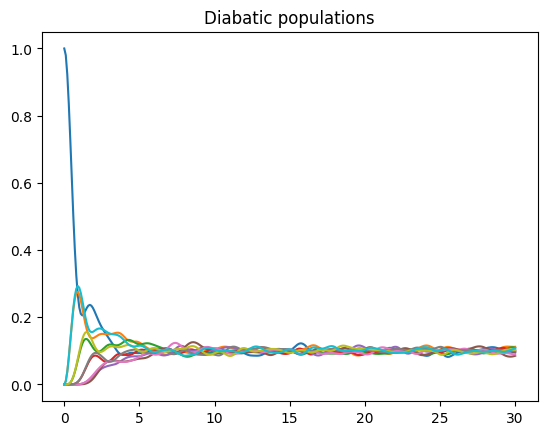

In [2]:

sim = Simulation()

sim.settings.num_trajs = 200
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.01

sim.model = HolsteinLattice({
    'N':10,
    'J':1.0,
    'w':1.0,
    'g':1.0,
    'phonon_mass':1.0,
    'kBT':1.0,
    'periodic':True

})
sim.algorithm = MeanField()

sim.initial_state["wf_db"] = np.zeros((sim.model.constants.N), dtype=complex)
sim.initial_state["wf_db"][0] += 1.0

data = serial_driver(sim)

t = data.data_dict['t']
plt.plot(t, np.real(np.einsum('tii->ti',data.data_dict['dm_db'])))
plt.title('Diabatic populations')
plt.show()

### Surface Hopping Calculations

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation # import simulation class 
from qclab.models import HolsteinLattice # import model class 
from qclab.algorithms import FewestSwitchesSurfaceHopping # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver

#### Stochastic sampling

100%|██████████| 3001/3001 [00:01<00:00, 1954.62it/s]


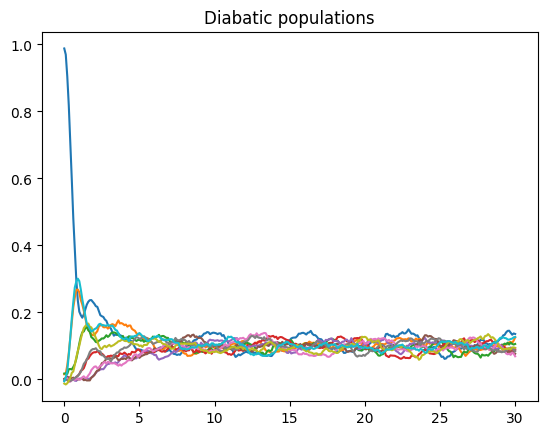

In [4]:
sim = Simulation()

sim.settings.num_trajs = 200
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.01

sim.model = HolsteinLattice({
    'N':10,
    'J':1.0,
    'w':1.0,
    'g':1.0,
    'phonon_mass':1.0,
    'kBT':1.0,
    'periodic':True

})
sim.algorithm = FewestSwitchesSurfaceHopping({
    'fssh_deterministic':False,
    'gauge_fixing':'sign_overlap'
})

sim.initial_state["wf_db"] = np.zeros((sim.model.constants.N), dtype=complex)
sim.initial_state["wf_db"][0] += 1.0

data = serial_driver(sim)

t = data.data_dict['t']
plt.plot(t, np.real(np.einsum('tii->ti',data.data_dict['dm_db'])))
plt.title('Diabatic populations')
plt.show()

#### Deterministic sampling

To use deterministic sampling we multiply the number of trajectories and batch size by the number of states. Note that the convergence behavior changes.

100%|██████████| 3001/3001 [00:13<00:00, 225.44it/s]


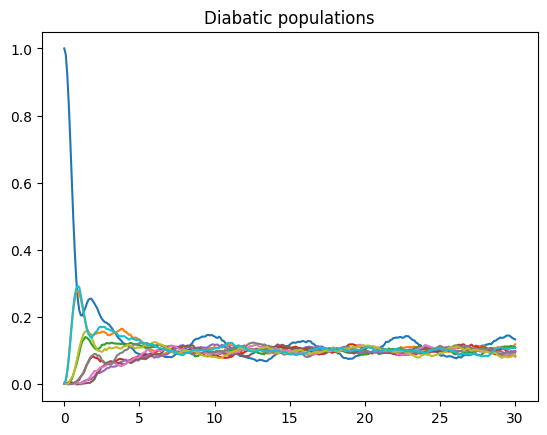

In [5]:
sim = Simulation()

sim.settings.num_trajs = 200*10
sim.settings.batch_size = 50*10
sim.settings.tmax = 30
sim.settings.dt_update = 0.01

sim.model = HolsteinLattice({
    'N':10,
    'J':1.0,
    'w':1.0,
    'g':1.0,
    'phonon_mass':1.0,
    'kBT':1.0,
    'periodic':True

})
sim.algorithm = FewestSwitchesSurfaceHopping({
    'fssh_deterministic':True,
    'gauge_fixing':'sign_overlap'
})

sim.initial_state["wf_db"] = np.zeros((sim.model.constants.N), dtype=complex)
sim.initial_state["wf_db"][0] += 1.0

data = serial_driver(sim)

t = data.data_dict['t']
plt.plot(t, np.real(np.einsum('tii->ti',data.data_dict['dm_db'])))
plt.title('Diabatic populations')
plt.show()

### Using a parllel driver

We will parallelize the above deterministic surface hopping calculation over four tasks.

100%|██████████| 3001/3001 [00:17<00:00, 170.06it/s]


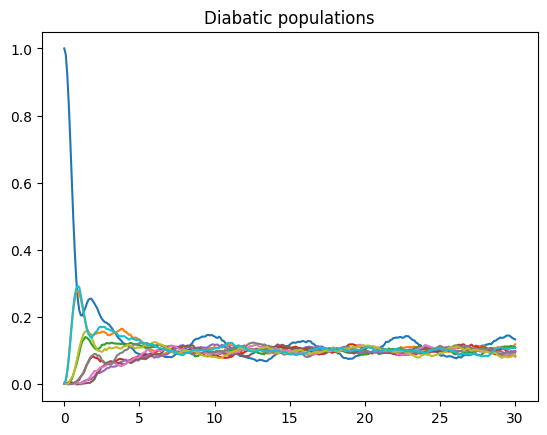

In [6]:
from qclab.dynamics import parallel_driver_multiprocessing # import dynamics driver

sim = Simulation()

sim.settings.num_trajs = 200*10
sim.settings.batch_size = 50*10
sim.settings.tmax = 30
sim.settings.dt_update = 0.01

sim.model = HolsteinLattice({
    'N':10,
    'J':1.0,
    'w':1.0,
    'g':1.0,
    'phonon_mass':1.0,
    'kBT':1.0,
    'periodic':True

})
sim.algorithm = FewestSwitchesSurfaceHopping({
    'fssh_deterministic':True,
    'gauge_fixing':'sign_overlap'
})

sim.initial_state["wf_db"] = np.zeros((sim.model.constants.N), dtype=complex)
sim.initial_state["wf_db"][0] += 1.0

data = parallel_driver_multiprocessing(sim)

t = data.data_dict['t']
plt.plot(t, np.real(np.einsum('tii->ti',data.data_dict['dm_db'])))
plt.title('Diabatic populations')
plt.show()

## Equivalence between real and reciprocal space

Note this only works if h=1 in the reciprocal space model (because of double counting).


In [ ]:
# Note that this test only works if h=1 in Reciprocal space model. This is because the weighting is double counted if not.

from qclab.models import HolsteinLatticeReciprocalSpace, HolsteinLattice
from qclab.dynamics import serial_driver
from qclab.algorithms import FewestSwitchesSurfaceHopping, MeanField
from qclab import Simulation
import numpy as np

# Real-space simulation.

sim = Simulation({"tmax":1,"num_trajs":1})
sim.model = HolsteinLattice()
sim.algorithm = FewestSwitchesSurfaceHopping()
sim.initial_state["wf_db"] = np.zeros(sim.model.constants.num_quantum_states, dtype=complex) + (1/np.sqrt(sim.model.constants.num_quantum_states))
init_real = np.copy(sim.initial_state["wf_db"])
ft = np.zeros((sim.model.constants.num_quantum_states, sim.model.constants.num_quantum_states), dtype=complex)
for n in range(sim.model.constants.num_quantum_states):
    for k in range(sim.model.constants.num_quantum_states):
        ft[n, k] = (1/np.sqrt(sim.model.constants.num_quantum_states)) * np.exp(-1.0j*2*np.pi*n*k/sim.model.constants.num_quantum_states)
data_real = serial_driver(sim)

# Reciprocal-space simulation.

sim=Simulation({"tmax":1,"num_trajs":1})
sim.model = HolsteinLatticeReciprocalSpace()
sim.algorithm = FewestSwitchesSurfaceHopping({"gauge_fixing":"sign_overlap"})
kvec = 2.0 * np.pi * sim.model.constants.k_inds / sim.model.constants.num_quantum_states
ft = np.zeros((sim.model.constants.num_quantum_states, sim.model.constants.num_quantum_states), dtype=complex)
for n in range(sim.model.constants.num_quantum_states):
    ft[n, :] = (1/np.sqrt(sim.model.constants.num_quantum_states)) * np.exp(-1.0j*kvec*n)

def z_to_recip(sim, state, parameters):
    state["z"] = np.einsum('nk,bn->bk', np.conj(ft),state["z"], optimize='greedy')[:,sim.model.constants.k_inds]
    return state, parameters

sim.algorithm.initialization_recipe.insert(4, z_to_recip)
print(sim.algorithm.initialization_recipe)
sim.initial_state["wf_db"] = np.einsum('nk,n->k', ft, init_real)
data_recip = serial_driver(sim)

dm_db_real = data_real.data_dict["dm_db"]
dm_p_real = np.einsum('tii->ti', dm_db_real)
dm_db_recip = data_recip.data_dict["dm_db"]
dm_p_recip = np.einsum('tii->ti', dm_db_recip)
dm_db_recip_2 = np.einsum('nk,tnm,mj->tkj',ft,dm_db_real,np.conj(ft))
dm_p_recip_2 = np.einsum('tii->ti', dm_db_recip_2)
print(np.allclose(dm_db_recip, dm_db_recip_2))
